# Instagram Kullanım Verileriyle Veri Madenciliği Projesi

**Öğrenci:** Murat GERENLİK &nbsp;&nbsp;|&nbsp;&nbsp; **No:** 25220901008  
**Ders:** Veri Madenciliği

---

## Proje Özeti

Bu proje, CRISP-DM metodolojisi izlenerek aynı veri seti üzerinde iki ayrı veri madenciliği problemi çözmektedir:

| | Problem | Tür | Hedef |
|---|---------|-----|-------|
| **1** | Etkileşim skoru tahmini | Regresyon | `user_engagement_score` (sürekli) |
| **2** | Etkileşim seviyesi tahmini | Sınıflandırma | Düşük / Orta / Yüksek (3 sınıf) |

Her iki problemde de **farklı kategorilerden en az üç model** eğitilmiş; **hiperparametre optimizasyonu**, **train-validation-test** ayrımı ve **k-katlı çapraz doğrulama** uygulanmıştır. Sınıflandırma için ayrıca **ROC eğrisi** ve **confusion matrix** üretilmiştir.

## 0. Kütüphanelerin İçe Aktarılması (Setup & Imports)

Bu bölümde veri işleme ve sayısal hesaplamalar için pandas / numpy, görselleştirme için matplotlib / seaborn, model eğitimi, ön işleme, değerlendirme metrikleri ve çapraz doğrulama için scikit-learn kütüphaneleri içe aktarılmıştır.

Sonuçların her çalıştırmada aynı olması (tekrarlanabilirlik / *reproducibility*) için sabit bir değer `RANDOM_STATE = 42` tanımlanmıştır. Bu tanımlama, rastgelelik içeren işlemlerin tutarlı sonuç vermesini sağlayacaktır.


In [1]:
# Gerekli kütüphanelerin içe aktarılması
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestClassifier, HistGradientBoostingRegressor,
                              HistGradientBoostingClassifier)
from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error,
                             accuracy_score, f1_score, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc, classification_report)
from sklearn.preprocessing import label_binarize

sns.set_style("whitegrid")
RANDOM_STATE = 42
print("✅ Kütüphaneler başarıyla yüklendi.")
print(f"Pandas {pd.__version__}, NumPy {np.__version__}")


✅ Kütüphaneler başarıyla yüklendi.
Pandas 1.5.3, NumPy 1.23.5


## 1. Veri Setinin Yüklenmesi (Load Dataset)

Instagram kullanım ve yaşam tarzı veri seti ham CSV dosyasından yüklenmektedir. Veri seti **1.547.896 kullanıcı** kaydı ve **58 değişken** içermektedir.

In [2]:
# Veri setinin yüklenmesi
veri = pd.read_csv('instagram_usage_lifestyle.csv')
print(f"Satır sayısı : {veri.shape[0]:,}")
print(f"Sütun sayısı : {veri.shape[1]}")
veri.head()


Satır sayısı : 1,547,896
Sütun sayısı : 58


,user_id,app_name,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,...,last_login_date,average_session_length_minutes,content_type_preference,preferred_content_theme,privacy_setting_level,two_factor_auth_enabled,biometric_login_used,linked_accounts_count,subscription_status,user_engagement_score
0,1,Instagram,51,Female,India,Rural,High,Retired,Bachelor’s,Single,...,2025-11-02,5.0,Mixed,Tech,Private,Yes,No,0,Free,7.83
1,2,Instagram,64,Female,United Kingdom,Urban,Middle,Full-time employed,Other,Divorced,...,2025-03-22,14.8,Photos,Fashion,Public,No,No,3,Free,1.43
2,3,Instagram,41,Female,Canada,Urban,Middle,Student,Bachelor’s,In a relationship,...,2025-08-10,5.0,Mixed,Other,Public,Yes,Yes,1,Free,9.67
3,4,Instagram,27,Non-binary,South Korea,Urban,Middle,Unemployed,Master’s,In a relationship,...,2025-03-31,25.9,Stories,Tech,Private,No,No,1,Free,0.94
4,5,Instagram,55,Male,India,Urban,Upper-middle,Full-time employed,Bachelor’s,Single,...,2025-03-19,13.1,Videos,Food,Public,Yes,No,0,Free,1.03


## 2. Veriyi Anlama (Data Understanding)

Bu adımda veri setinin değişken yapısı gösterilecektir. Ön işleme aşamasında sayısal değişkenlere ölçekleme, kategorik değişkenlere ise kodlama (encoding) uygulanacağı için bu adım önemlidir.


In [7]:
# Veri türleri ve genel bilgi
print("Sayısal sütun sayısı :", len(veri.select_dtypes(include=[np.number]).columns))
print("Kategorik sütun sayısı:", len(veri.select_dtypes(include=['object']).columns))
print(f"\nBellek kullanımı: {veri.memory_usage(deep=True).sum()/1024**2:.1f} MB")
print("\nVeri türü dağılımı:")
print(veri.dtypes.value_counts())
veri.describe()

Sayısal sütun sayısı : 38
Kategorik sütun sayısı: 20

Bellek kullanımı: 2343.3 MB

Veri türü dağılımı:
int64      29
object     20
float64     9
dtype: int64


,user_id,age,exercise_hours_per_week,sleep_hours_per_night,perceived_stress_score,self_reported_happiness,body_mass_index,blood_pressure_systolic,blood_pressure_diastolic,daily_steps_count,...,time_on_explore_per_day,time_on_messages_per_day,time_on_reels_per_day,followers_count,following_count,notification_response_rate,account_creation_year,average_session_length_minutes,linked_accounts_count,user_engagement_score
count,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,...,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06
mean,7.739485e+05,3.898544e+01,7.143480e+00,6.999384e+00,1.998774e+01,5.499804e+00,2.500084e+01,1.244917e+02,7.950007e+01,8.000105e+03,...,3.762037e+01,3.295203e+01,5.647662e+01,2.160543e+03,2.604942e+03,5.002404e-01,2.017501e+03,2.050971e+01,1.975254e+00,1.644642e+00
std,4.468392e+05,1.529453e+01,3.994556e+00,1.097098e+00,1.183258e+01,2.871232e+00,3.976188e+00,2.020699e+01,1.154874e+01,8.939761e+01,...,2.535788e+01,2.144569e+01,3.534782e+01,3.402016e+03,2.751922e+03,2.887827e-01,4.611735e+00,8.697454e+00,1.352058e+00,1.812684e+00
min,1.000000e+00,1.300000e+01,0.000000e+00,3.000000e+00,0.000000e+00,1.000000e+00,1.500000e+01,9.000000e+01,6.000000e+01,7.566000e+03,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+01,2.000000e+01,0.000000e+00,2.010000e+03,5.000000e+00,0.000000e+00,6.700000e-01
25%,3.869748e+05,2.600000e+01,4.000000e+00,6.300000e+00,1.000000e+01,3.000000e+00,2.230000e+01,1.070000e+02,7.000000e+01,7.940000e+03,...,1.800000e+01,1.600000e+01,2.900000e+01,5.430000e+02,6.630000e+02,2.500000e-01,2.013000e+03,1.330000e+01,1.000000e+00,1.000000e+00
50%,7.739485e+05,3.900000e+01,6.600000e+00,7.000000e+00,2.000000e+01,5.000000e+00,2.500000e+01,1.240000e+02,7.900000e+01,8.000000e+03,...,3.400000e+01,3.100000e+01,5.400000e+01,1.154000e+03,1.519000e+03,5.000000e-01,2.017000e+03,2.040000e+01,2.000000e+00,1.100000e+00
75%,1.160922e+06,5.200000e+01,9.700000e+00,7.700000e+00,3.000000e+01,8.000000e+00,2.770000e+01,1.420000e+02,9.000000e+01,8.060000e+03,...,5.300000e+01,4.700000e+01,8.000000e+01,2.459000e+03,3.451000e+03,7.500000e-01,2.022000e+03,2.760000e+01,3.000000e+00,1.290000e+00
max,1.547896e+06,6.500000e+01,2.410000e+01,1.000000e+01,4.000000e+01,1.000000e+01,4.500000e+01,1.590000e+02,9.900000e+01,8.473000e+03,...,1.710000e+02,1.380000e+02,2.220000e+02,2.088110e+05,1.000000e+04,1.000000e+00,2.025000e+03,5.200000e+01,5.000000e+00,1.867000e+01


## 3. Veri Temizleme (Data Cleaning)

Model kurmadan önce veri kalitesi üç açıdan değerlendirilecektir. Modeller eksik veriyle çalışamayacağı için eksik değerlerin tamamlanması,  aynı kaydın birden çok kez bulunması modeli yanıltabileceği için tekrar eden satırların önlenmesi, tek bir değer taşıyan sütunlar hiçbir ayırt edici bilgi içermediği için  sabit (tek değerli) sütunların kaldırılması gerekmektedir.

Bu kontroller sonucunda veri setinin temiz olduğu, eksik verinin ve tekrarın olmadığı görülmektedir. `app_name` sütunu her satırda 'Instagram' değerini taşıdığı için kaldırılacaktır; `user_id` ise benzersiz kimlik olduğundan modelleme dışı bırakılacaktır. 

In [3]:
# VERİ TEMİZLEME: Eksik değer, tekrar ve sabit sütun kontrolü
print("Toplam eksik hücre :", veri.isnull().sum().sum())
print("Tekrar eden satır  :", veri.duplicated().sum())
print("Benzersiz user_id  :", veri['user_id'].nunique(), "/", len(veri))
print("\nSabit (tek değerli) sütunlar:")
for col in veri.columns:
    if veri[col].nunique() == 1:
        print(f"  - {col}: '{veri[col].iloc[0]}'")


Toplam eksik hücre : 0
Tekrar eden satır  : 0
Benzersiz user_id  : 1547896 / 1547896

Sabit (tek değerli) sütunlar:
  - app_name: 'Instagram'


## 4. Örnekleme (Sampling)

Veri seti 1,5 milyon satır içermektedir. Bu büyüklükteki veriyle her model denemesini çalıştırmak yüksek maliyet yaratacaktır. Bu sebeple istatistiksel temsil gücünü korurken hesaplama süresini kısaltmak için **200.000 satırlık rastgele bir örneklem** alınacaktır. `random_state` sabitlendiği için bu örneklem her çalıştırmada aynıdır.


In [4]:
# Modelleme için temsili örneklem (200.000 satır)
# 1.5M satırın tamamı gereksiz hesaplama maliyeti yaratır
veri = veri.sample(n=200000, random_state=RANDOM_STATE).reset_index(drop=True)
print(f"Örneklem boyutu: {veri.shape}")


Örneklem boyutu: (200000, 58)


## 4.1. Özellik Mühendisliği (Feature Engineering)

Bu adımda mevcut değişkenlerden yeni anlamlı değişkenler türetilecektir. Toplam 8 yeni değişken oluşturulacaktır. Örneğin `engagement_per_follower` (takipçi başına etkileşim) sosyal verimliliği, `follower_ratio` ise kullanıcının etki/popülerlik düzeyini temsil eder.

In [5]:
# ÖZELLİK MÜHENDİSLİĞİ: Mevcut değişkenlerden yeni anlamlı değişkenler türetme

# 1) Toplam uygulama süresi (tüm bölümlerde geçen süre)
veri['total_time_on_app'] = (veri['time_on_feed_per_day'] + veri['time_on_explore_per_day'] +
                           veri['time_on_messages_per_day'] + veri['time_on_reels_per_day'])

# 2) Takipçi başına etkileşim (beğeni+yorum / takipçi) -> sosyal verimlilik
veri['engagement_per_follower'] = ((veri['likes_given_per_day'] + veri['comments_written_per_day'])
                                 / (veri['followers_count'] + 1))

# 3) Takipçi/takip oranı -> popülerlik/etki göstergesi
veri['follower_ratio'] = veri['followers_count'] / (veri['following_count'] + 1)

# 4) İçerik tüketim hızı (reels + story izleme)
veri['content_consumption_rate'] = veri['reels_watched_per_day'] + veri['stories_viewed_per_day']

# 5) Aktif üretim oranı (oturum başına post üretimi)
veri['active_creation_ratio'] = veri['posts_created_per_week'] / (veri['sessions_per_day']*7 + 1)

# 6) Mesajlaşma aktivitesi (gönderilen + alınan DM)
veri['dm_activity'] = veri['dms_sent_per_week'] + veri['dms_received_per_week']

# 7) Oturum başına ortalama süre
veri['avg_time_per_session'] = veri['total_time_on_app'] / (veri['sessions_per_day'] + 1)

# 8) Reklam etkileşim oranı (tıklanan / görülen reklam)
veri['ad_engagement_rate'] = veri['ads_clicked_per_day'] / (veri['ads_viewed_per_day'] + 1)

yeni_degiskenler = ['total_time_on_app','engagement_per_follower','follower_ratio',
                    'content_consumption_rate','active_creation_ratio','dm_activity',
                    'avg_time_per_session','ad_engagement_rate']
print(f"{len(yeni_degiskenler)} yeni değişken türetildi:")
for d in yeni_degiskenler:
    print(f"  - {d}")
print(f"\nYeni Veri Boyutu: {veri.shape}")

8 yeni değişken türetildi:
  - total_time_on_app
  - engagement_per_follower
  - follower_ratio
  - content_consumption_rate
  - active_creation_ratio
  - dm_activity
  - avg_time_per_session
  - ad_engagement_rate

Yeni Veri Boyutu: (200000, 66)


### 4.2. Türetilen Değişkenlerin Sızıntı Kontrolü

Türetilen değişkenlerin bir kısmı (özellikle süre tabanlı olanlar) hedefle matematiksel bağ taşıyarak veri sızıntısına yol açabilir. Her yeni değişkenin hedefle korelasyonunu incelenerek, güçlü korelasyon (|r| > 0.5) gösterenler modellemeden hariç tutulacak; yalnızca güvenli olanlar modele dahil edilecektir. Sızıntılı değişkenler keşifsel veri analizinde (EDA) içgörü sağladığı için saklanacaktır.

In [6]:
# TÜRETİLEN DEĞİŞKENLERİN SIZINTI KONTROLÜ

print("Türetilen Değişkenlerin Hedefle Korelasyonu:")
print("="*60)
guvenli = []
sizintili = []
for d in yeni_degiskenler:
    corr = veri[d].corr(veri['user_engagement_score'])
    if abs(corr) > 0.5:
        sizintili.append(d)
        print(f"  {d:28s}: {corr:+.3f}  [SIZINTI -> modele alınmayacak]")
    else:
        guvenli.append(d)
        print(f"  {d:28s}: {corr:+.3f}  [güvenli -> modele alınacak]")

print(f"\nGüvenli (Modele Eklenecek): {len(guvenli)} -> {guvenli}")
print(f"Sızıntılı (Sadece EDA): {len(sizintili)} -> {sizintili}")

Türetilen Değişkenlerin Hedefle Korelasyonu:
  total_time_on_app           : -0.519  [SIZINTI -> modele alınmayacak]
  engagement_per_follower     : -0.136  [güvenli -> modele alınacak]
  follower_ratio              : -0.005  [güvenli -> modele alınacak]
  content_consumption_rate    : -0.524  [SIZINTI -> modele alınmayacak]
  active_creation_ratio       : +0.637  [SIZINTI -> modele alınmayacak]
  dm_activity                 : -0.503  [SIZINTI -> modele alınmayacak]
  avg_time_per_session        : -0.528  [SIZINTI -> modele alınmayacak]
  ad_engagement_rate          : -0.059  [güvenli -> modele alınacak]

Güvenli (Modele Eklenecek): 3 -> ['engagement_per_follower', 'follower_ratio', 'ad_engagement_rate']
Sızıntılı (Sadece EDA): 5 -> ['total_time_on_app', 'content_consumption_rate', 'active_creation_ratio', 'dm_activity', 'avg_time_per_session']


## 5. Keşifsel Veri Analizi - Hedef Değişken (EDA)

Problemde hedef değişkenimiz `user_engagement_score` (kullanıcı etkileşim skoru) olacaktır. Bu adımda değişkenin istatistiksel özeti incelenecektir.

**Çarpıklık (skewness)** değerinin yüksek ve pozitif olması, dağılımın **sağa çarpık** olduğunu göstermektedir; yani çoğu kullanıcının skoru düşük, az sayıda kullanıcının skoru çok yüksektir. Bu durum,  logaritmik dönüşüm uygulamamızı gerektirecektir.


In [8]:
# Hedef değişkenin istatistiksel özeti
print("user_engagement_score istatistikleri:")
print(veri['user_engagement_score'].describe().round(3))
print(f"\nÇarpıklık (skewness): {veri['user_engagement_score'].skew():.3f}")


user_engagement_score istatistikleri:
count    200000.000
mean          1.641
std           1.808
min           0.690
25%           1.000
50%           1.090
75%           1.290
max          18.000
Name: user_engagement_score, dtype: float64

Çarpıklık (skewness): 3.776


### 5.1. Hedef Değişkenin Dağılımı ve Log Dönüşümü

Aşağıdaki histogramlar hedef değişkenin dağılımını göstermektedir. Sol grafik belirgin biçimde sağa çarpıktır. Sağ grafikte ise logaritmik dönüşüm (`log1p`) sonrası dağılımın normale yaklaştığı görülmektedir.

Bu dönüşüm, birçok makine öğrenmesi algoritmasının, hedef değişken normale yakın dağıldığında daha iyi performans gösterdiği için önemlidir. Bu nedenle modelleme aşamasında log dönüşümü uygulanacaktır.


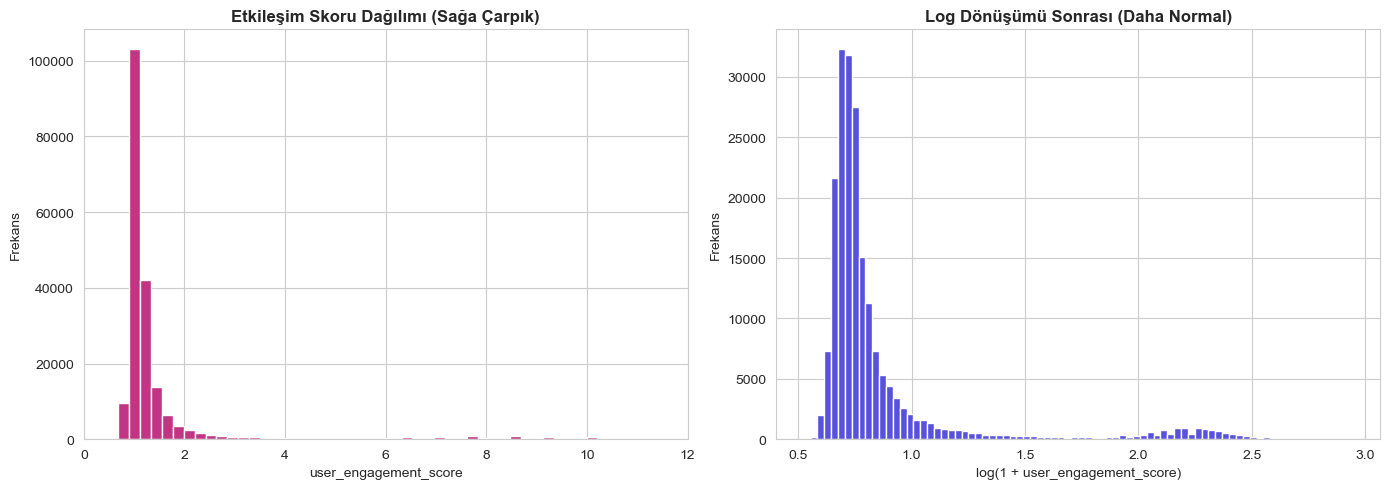

In [9]:
# GÖRSEL 1: Hedef değişkenin dağılımı ve log dönüşümü
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].hist(veri['user_engagement_score'], bins=80, color='#C13584', edgecolor='white')
ax[0].set_title('Etkileşim Skoru Dağılımı (Sağa Çarpık)', fontweight='bold')
ax[0].set_xlabel('user_engagement_score'); ax[0].set_xlim(0, 12)
ax[0].set_ylabel('Frekans')

ax[1].hist(np.log1p(veri['user_engagement_score']), bins=80, color='#5851DB', edgecolor='white')
ax[1].set_title('Log Dönüşümü Sonrası (Daha Normal)', fontweight='bold')
ax[1].set_xlabel('log(1 + user_engagement_score)'); ax[1].set_ylabel('Frekans')
plt.tight_layout(); plt.show()


### 5.2. Korelasyon Analizi

Bu grafik, hedef değişken ile sayısal değişkenler arasındaki korelasyonları göstermektedir (Mavi: pozitif, Pembe: negatif).

Grafikten de anlaşılacağı üzere en güçlü korelasyonların tamamı negatiftir. Yani kullanıcı uygulamada ne kadar çok zaman geçirir veya ne kadar çok içerik tüketirse, etkileşim skoru o kadar düşmektedir. Bu, skorun bir 'verimlilik/değer' oranı niteliği taşıdığına işaret etmektedir.


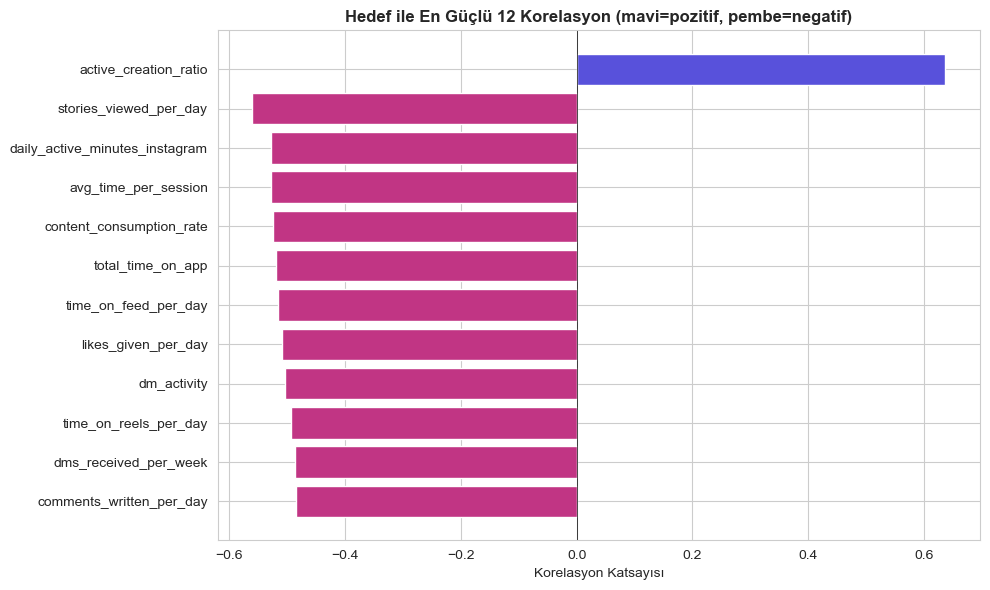

Not: En güçlü korelasyonlar NEGATİF -> Fazla zaman düşük etkileşim skoru anlamı çıkmaktadır.


In [10]:
# GÖRSEL 2: Korelasyon Analizi (hedef ile en güçlü ilişkiler)
num_cols = [c for c in veri.select_dtypes(include=[np.number]).columns if c != 'user_id']
corr = veri[num_cols].corr()['user_engagement_score'].drop('user_engagement_score')
corr_top = corr.abs().sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(10, 6))
renkler = ['#C13584' if corr[i] < 0 else '#5851DB' for i in corr_top.index]
ax.barh(range(len(corr_top)), [corr[i] for i in corr_top.index], color=renkler)
ax.set_yticks(range(len(corr_top))); ax.set_yticklabels(corr_top.index)
ax.invert_yaxis(); ax.set_xlabel('Korelasyon Katsayısı')
ax.set_title('Hedef ile En Güçlü 12 Korelasyon (mavi=pozitif, pembe=negatif)', fontweight='bold')
ax.axvline(0, color='black', lw=0.5)
plt.tight_layout(); plt.show()
print("Not: En güçlü korelasyonlar NEGATİF -> Fazla zaman düşük etkileşim skoru anlamı çıkmaktadır.")


### 5.2.1. Korelasyon Isı Haritası (Heatmap)

Değişkenler arası ilişkileri daha bütüncül görmek için bir korelasyon ısı haritası oluşturulmuştur. Bu görsel, hem hedefle ilişkileri hem de birbiriyle yüksek korelasyonlu değişken çiftleri tespit etmemize yardımcı olacaktır.

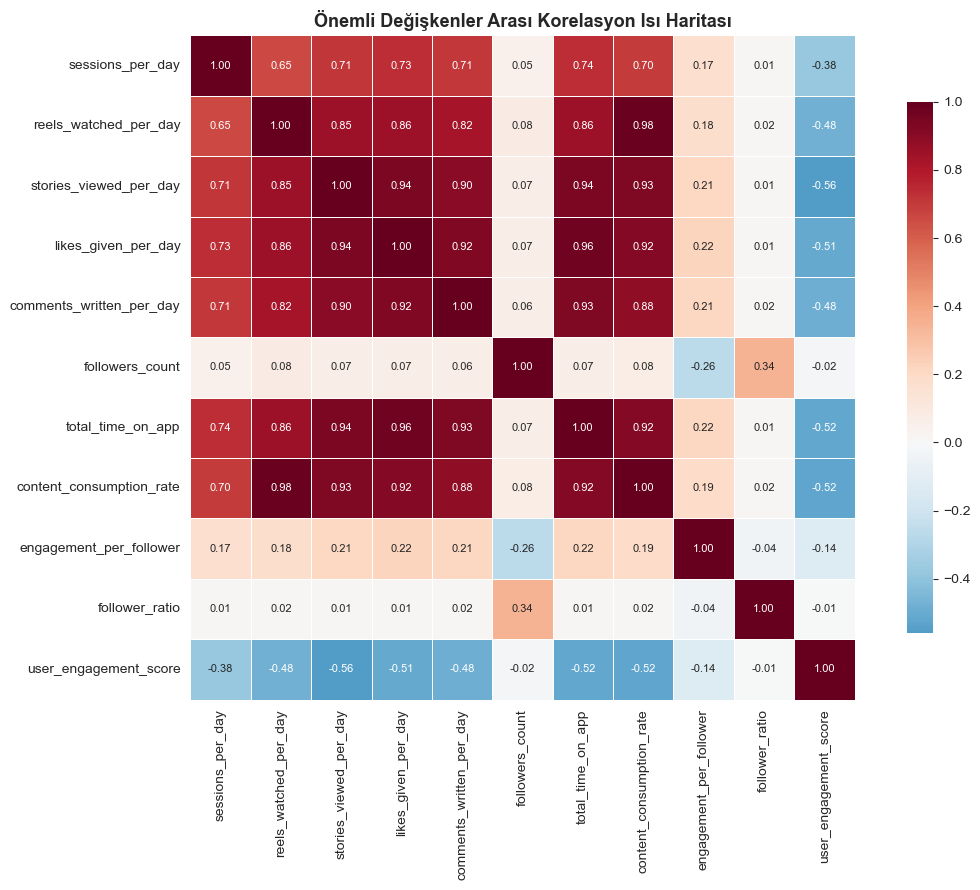

Not: Koyu Kırmızı = Güçlü Pozitif, Koyu Mavi = Güçlü Negatif Korelasyon.


In [11]:
# GÖRSEL: Korelasyon Heatmap (Isı Haritası)

# Okunabilirlik için önemli değişkenleri seç (kullanım metrikleri + türetilenler + hedef)
onemli_sutunlar = ['sessions_per_day','reels_watched_per_day','stories_viewed_per_day',
                   'likes_given_per_day','comments_written_per_day','followers_count',
                   'total_time_on_app','content_consumption_rate','engagement_per_follower',
                   'follower_ratio','user_engagement_score']

plt.figure(figsize=(12, 9))
corr_matrix = veri[onemli_sutunlar].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 8})
plt.title('Önemli Değişkenler Arası Korelasyon Isı Haritası', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()
print("Not: Koyu Kırmızı = Güçlü Pozitif, Koyu Mavi = Güçlü Negatif Korelasyon.")

### 5.3. Kullanım-Skor İlişkisi ve Anomali Analizi

Sol grafikte günlük kullanım süresi ile etkileşim skoru arasındaki ilişki görülmektedir. İlişki doğrusal değil, hiperboliktir. Yani süre arttıkça skor hızla düşüp sabitlenmektedir.

Sağ grafikte abonelik türüne göre skor dağılımı (kutu grafiği) görülmektedir.

Grafiklerden bu ilişkinin doğrusal olmadığı anlaşılmaktadır. Bu durum ağaç tabanlı modellerin (Karar Ağacı, Gradient Boosting) projemizde doğrusal regresyondan daha başarılı olacağını göstermektedir, çünkü bu modeller eğrisel ilişkileri yakalayabilmektedir.


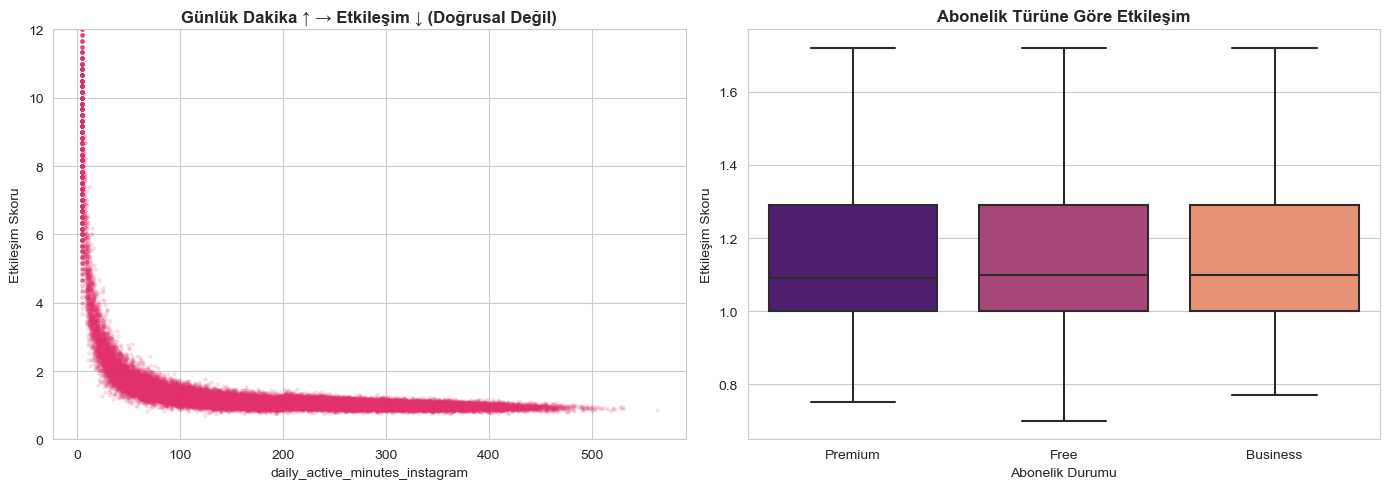

In [12]:
# GÖRSEL 3: Kullanım süresi ile skor ilişkisi (hiperbolik)
ornek = veri.sample(n=50000, random_state=RANDOM_STATE)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].scatter(ornek['daily_active_minutes_instagram'], ornek['user_engagement_score'],
              alpha=0.1, s=5, color='#E1306C')
ax[0].set_title('Günlük Dakika ↑ → Etkileşim ↓ (Doğrusal Değil)', fontweight='bold')
ax[0].set_xlabel('daily_active_minutes_instagram'); ax[0].set_ylabel('Etkileşim Skoru')
ax[0].set_ylim(0, 12)

sns.boxplot(data=ornek, x='subscription_status', y='user_engagement_score',
            ax=ax[1], showfliers=False, palette='magma')
ax[1].set_title('Abonelik Türüne Göre Etkileşim', fontweight='bold')
ax[1].set_xlabel('Abonelik Durumu'); ax[1].set_ylabel('Etkileşim Skoru')
plt.tight_layout(); plt.show()


### 5.4. Kategorik Değişkenlerin Analizi

Bu adımda kategorik değişkenlerin dağılımı ve hedef değişkenle ilişkisi incelenecektir. Her değişken için üst grafikte kategori dağılımı, alt grafikte ise her kategorinin ortalama etkileşim skoru gösterilmektedir. Bu, hangi kullanıcı gruplarının daha yüksek/düşük etkileşime sahip olduğunu ortaya koymaktadır.

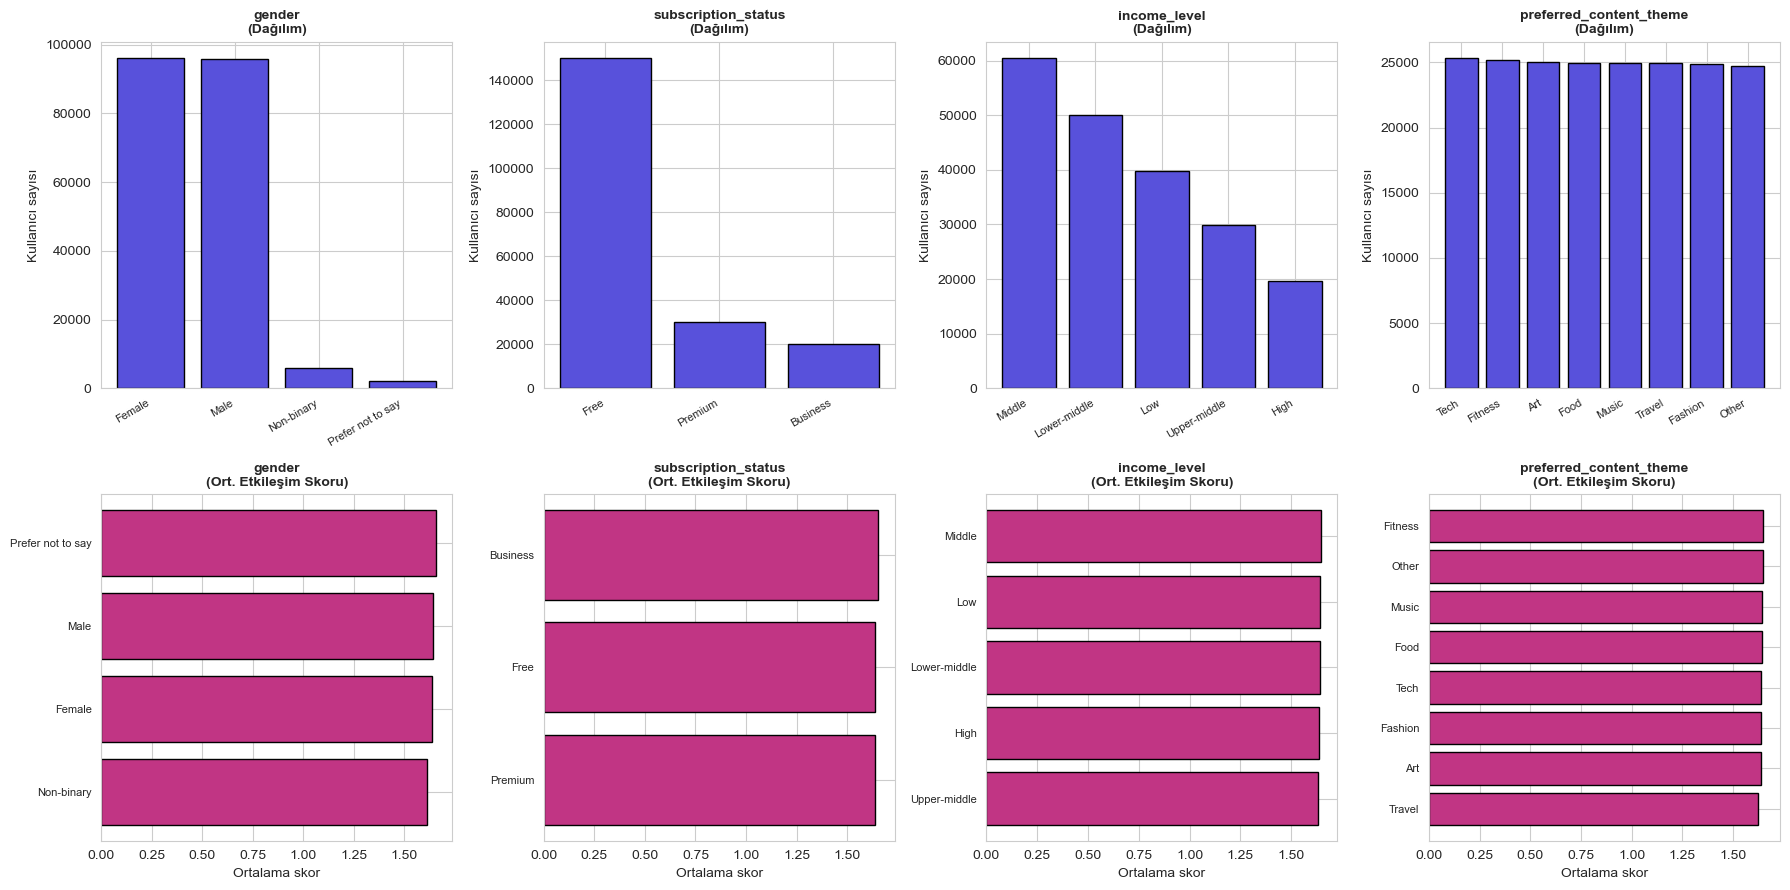

Üst Satır: Kategori Dağılımları | Alt Satır: Her Kategorinin Ortalama Etkileşim Skoru


In [13]:
# GÖRSEL: Kategorik Değişkenlerin Dağılımı ve Hedefle İlişkisi
# Her kategorik değişken için: (üst) dağılım, (alt) hedef ortalaması karşılaştırması.

kategorik_degiskenler = ['gender','subscription_status','income_level','preferred_content_theme']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for j, kat in enumerate(kategorik_degiskenler):
    # Üst satır: dağılım (sayım)
    vc = veri[kat].value_counts()
    axes[0, j].bar(range(len(vc)), vc.values, color='#5851DB', edgecolor='black')
    axes[0, j].set_xticks(range(len(vc)))
    axes[0, j].set_xticklabels(vc.index, rotation=30, ha='right', fontsize=8)
    axes[0, j].set_title(f'{kat}\n(Dağılım)', fontweight='bold', fontsize=10)
    axes[0, j].set_ylabel('Kullanıcı sayısı')

    # Alt satır: hedef ortalaması (kategoriye göre etkileşim)
    grp = veri.groupby(kat)['user_engagement_score'].mean().sort_values()
    axes[1, j].barh(range(len(grp)), grp.values, color='#C13584', edgecolor='black')
    axes[1, j].set_yticks(range(len(grp)))
    axes[1, j].set_yticklabels(grp.index, fontsize=8)
    axes[1, j].set_title(f'{kat}\n(Ort. Etkileşim Skoru)', fontweight='bold', fontsize=10)
    axes[1, j].set_xlabel('Ortalama skor')

plt.tight_layout(); plt.show()
print("Üst Satır: Kategori Dağılımları | Alt Satır: Her Kategorinin Ortalama Etkileşim Skoru")

## 6. Veri Hazırlama ve Özellik Mühendisliği (Data Preparation)

Bu aşamada modelleme için veri hazırlanacaktır. Veri hazırlama için iki grup sütun çıkarılacaktır:

1. **Bilgi taşımayan sütunlar:** `user_id` (kimlik), `app_name` (sabit), `last_login_date` (tarih).
2. **Veri sızıntısı sütunları:** Hedefle doğrudan matematiksel ilişkisi olan 6 adet 'süre' türevi sütun.

**Veri sızıntısı nedir ve neden önemli?** Bir özellik, hedef değişkeni neredeyse doğrudan hesaplıyorsa modelin başarısı yapay olarak yüksek çıkar; ama model gerçek kalıpları öğrenmek yerine gizli bir formülü ezberlemiş olur. Bu sebeple bu sütunlar çıkarılarak modelin gerçek davranış kalıplarından öğrenmesi sağlanacaktır.


In [14]:
# VERİ HAZIRLAMA: Gereksiz ve sızıntı sütunlarının çıkarılması
# Sızıntı sütunları: hedefle matematiksel bağı olan 'süre' türevleri (ham + türetilmiş)
leak_cols = ['daily_active_minutes_instagram','time_on_feed_per_day','time_on_explore_per_day',
             'time_on_messages_per_day','time_on_reels_per_day','average_session_length_minutes']
# Özellik mühendisliğinde tespit edilen sızıntılı türetilmiş değişkenleri de ekle
leak_cols = leak_cols + sizintili
drop_cols = ['user_id','app_name','last_login_date']

veri_model = veri.drop(columns=drop_cols)
print(f"Bilgi taşımayan sütunlar atıldı: {drop_cols}")
print(f"Sızıntı sütunları (ham+türetilmiş): {len(leak_cols)} adet")
print(f"Modele eklenen güvenli türetilmiş değişkenler: {guvenli}")
print(f"Kalan sütun sayısı: {veri_model.shape[1]}")

Bilgi taşımayan sütunlar atıldı: ['user_id', 'app_name', 'last_login_date']
Sızıntı sütunları (ham+türetilmiş): 11 adet
Modele eklenen güvenli türetilmiş değişkenler: ['engagement_per_follower', 'follower_ratio', 'ad_engagement_rate']
Kalan sütun sayısı: 63


## 7. PROBLEM 1 - Regresyon: Etkileşim Skorunun Tahmini

### 7.1. Özellik/Hedef Ayrımı ve Ön İşleme Pipeline'ı

Bu bölümde sürekli bir değer olan etkileşim skoru tahmin edilmektedir (regresyon problemi).

**Uygulanan dönüşümler:**
- Hedefe **logaritmik dönüşüm** (sağa çarpıklık nedeniyle).
- Sayısal özelliklere **StandardScaler** (ortalama 0, standart sapma 1) - farklı ölçekteki değişkenleri eşitler.
- Kategorik özelliklere **OneHotEncoder** - her kategoriyi 0/1 sütununa çevirir.

**Veri sızıntısının önlenmesi:** `fit_transform` yalnızca eğitim setine, `transform` ise test setine uygulanacaktır. Böylece test verisinin istatistikleri eğitim sürecine sızmayacak ve dürüst bir performans ölçümü elde edilecektir.


In [15]:
# ============================================================
# PROBLEM 1: REGRESYON - Etkileşim skorunun tahmini
# ============================================================
# Hedef ve özelliklerin ayrılması (sızıntı sütunları çıkarılmış)
y_reg = np.log1p(veri_model['user_engagement_score'])   # log ölçeği
y_reg_orig = veri_model['user_engagement_score']         # gerçek ölçek
X_reg = veri_model.drop(columns=['user_engagement_score'] + leak_cols)

num_features = X_reg.select_dtypes(include=[np.number]).columns.tolist()
cat_features = [c for c in X_reg.columns if c not in num_features]
print(f"Sayısal Özellik: {len(num_features)}, Kategorik Özellik: {len(cat_features)}")

# Eğitim/test ayrımı + ön işleme pipeline
Xtr, Xte, ytr, yte, _, yte_o = train_test_split(
    X_reg, y_reg, y_reg_orig, test_size=0.2, random_state=RANDOM_STATE)

prep_reg = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)])
Xtr_p = prep_reg.fit_transform(Xtr)
Xte_p = prep_reg.transform(Xte)
print(f"Ön İşleme Sonrası Özellik Sayısı: {Xtr_p.shape[1]}")
print(f"Eğitim: {Xtr_p.shape[0]:,} | Test: {Xte_p.shape[0]:,}")


Sayısal Özellik: 33, Kategorik Özellik: 18
Ön İşleme Sonrası Özellik Sayısı: 113
Eğitim: 160,000 | Test: 40,000


### 7.2. Regresyon Modellerinin Eğitimi (4 Farklı Model)

Regresyon modellerinin performansı, tahminler gerçek ölçeğe geri çevrilerek (`expm1`) üç metrikle değerlendirilmiştir: **R²** (Belirleme Katsayısı), **MAE** (Mean Absolute Error/Ortalama Mutlak Hata) ve **RMSE** (Root Mean Square Error/Karekök Ortalama Kare Hata).


In [16]:
# REGRESYON MODELLERİ: 4 FARKLI ALGORİTMA AİLESİNDEN model eğitimi
# Aileler: Ağaç-tabanlı | Mesafe-tabanlı (KNN) | Çekirdek-tabanlı (SVM) | Boosting
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# SVM çekirdek hesabı O(n^2) olduğundan büyük veride çok yavaştır;
# bu nedenle SVM yalnızca 10.000 satırlık alt örneklemde eğitilecektir.
svm_idx = np.random.RandomState(RANDOM_STATE).choice(len(Xtr_p), 10000, replace=False)

def reg_degerlendir(isim, model, kucuk_ornek=False):
    t0 = time.time()
    if kucuk_ornek:
        model.fit(Xtr_p[svm_idx], ytr.iloc[svm_idx] if hasattr(ytr,'iloc') else ytr[svm_idx])
    else:
        model.fit(Xtr_p, ytr)
    sure = time.time() - t0
    pred_o = np.expm1(model.predict(Xte_p))
    r2 = r2_score(yte_o, pred_o)
    mae = mean_absolute_error(yte_o, pred_o)
    rmse = np.sqrt(mean_squared_error(yte_o, pred_o))
    print(f"{isim:24s} | R²={r2:.4f} | MAE={mae:.4f} | RMSE={rmse:.4f} | Süre={sure:.2f}s")
    return model, r2, mae, sure

print("REGRESYON MODELLERİ — 4 ALGORİTMA AİLESİ (Gerçek Ölçek, Test Seti)")
print("="*78)
reg_results = {}
# 1) Ağaç-tabanlı
_, r2, mae, sure = reg_degerlendir("1. Karar Ağacı (d=12)",
                  DecisionTreeRegressor(max_depth=12, random_state=RANDOM_STATE))
reg_results['Karar Ağacı'] = (r2, mae, sure)
# 2) Mesafe-tabanlı
_, r2, mae, sure = reg_degerlendir("2. KNN (k=15)",
                  KNeighborsRegressor(n_neighbors=15, n_jobs=-1))
reg_results['KNN'] = (r2, mae, sure)
# 3) Çekirdek-tabanlı (alt örneklemde)
_, r2, mae, sure = reg_degerlendir("3. SVM (RBF çekirdek)",
                  SVR(kernel='rbf', C=1.0), kucuk_ornek=True)
reg_results['SVM'] = (r2, mae, sure)
# 4) Boosting (topluluk)
gb_reg, r2, mae, sure = reg_degerlendir("4. Gradient Boosting",
                  HistGradientBoostingRegressor(learning_rate=0.05, max_depth=8,
                  max_iter=500, l2_regularization=1.0, random_state=RANDOM_STATE,
                  early_stopping=True, n_iter_no_change=15))
reg_results['Gradient Boosting'] = (r2, mae, sure)

REGRESYON MODELLERİ — 4 ALGORİTMA AİLESİ (Gerçek Ölçek, Test Seti)
1. Karar Ağacı (d=12)    | R²=0.8192 | MAE=0.2321 | RMSE=0.7656 | Süre=4.07s
2. KNN (k=15)            | R²=0.5799 | MAE=0.4044 | RMSE=1.1670 | Süre=0.02s
3. SVM (RBF çekirdek)    | R²=0.7254 | MAE=0.3774 | RMSE=0.9435 | Süre=3.49s
4. Gradient Boosting     | R²=0.8943 | MAE=0.1844 | RMSE=0.5853 | Süre=14.48s


### 7.3. Regresyon Modellerinin Karşılaştırılması

Aşağıdaki üç grafik, modellerin performansını farklı açılardan karşılaştırır:
- **Sol (R²):** Açıklanan varyans — yüksek = iyi.
- **Orta (MAE):** Ortalama mutlak hata — düşük = iyi.
- **Sağ (Eğitim Süresi):** Modelin eğitilme süresi (saniye) — düşük = hızlı.

**Performans-hız dengesi:** Gradient Boosting en yüksek doğruluğu sağlamaktadır ancak en uzun eğitim süresini gerektirmektedir. KNN ise en hızlı eğitilen modeldir fakat en düşük doğruluğa sahiptir. Bu karşılaştırma, gerçek problemlerde doğruluk ile hesaplama maliyeti arasında bir denge kurmanın önemini göstermektedir.


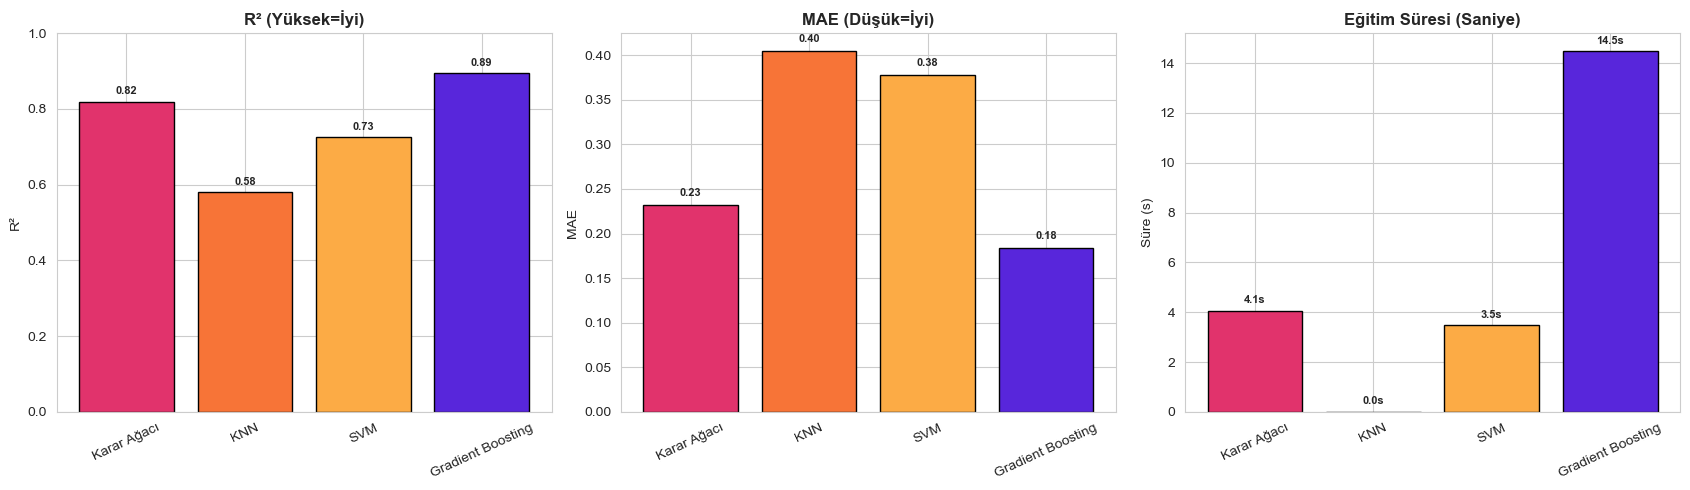

In [17]:
# GÖRSEL: 4 Regresyon Modelinin Karşılaştırması (R², MAE, Süre)
fig, ax = plt.subplots(1, 3, figsize=(17, 5))
isimler = list(reg_results.keys())
r2lar = [reg_results[k][0] for k in isimler]
maeler = [reg_results[k][1] for k in isimler]
sureler = [reg_results[k][2] for k in isimler]
renk = ['#E1336C','#F77437','#FCAB45','#5826DB']

b1 = ax[0].bar(isimler, r2lar, color=renk, edgecolor='black')
ax[0].set_title('R² (Yüksek=İyi)', fontweight='bold'); ax[0].set_ylabel('R²'); ax[0].set_ylim(0,1)
ax[0].tick_params(axis='x', rotation=25)
for b,v in zip(b1,r2lar): ax[0].text(b.get_x()+b.get_width()/2,v+0.02,f'{v:.2f}',ha='center',fontsize=8,fontweight='bold')

b2 = ax[1].bar(isimler, maeler, color=renk, edgecolor='black')
ax[1].set_title('MAE (Düşük=İyi)', fontweight='bold'); ax[1].set_ylabel('MAE')
ax[1].tick_params(axis='x', rotation=25)
for b,v in zip(b2,maeler): ax[1].text(b.get_x()+b.get_width()/2,v+0.01,f'{v:.2f}',ha='center',fontsize=8,fontweight='bold')

b3 = ax[2].bar(isimler, sureler, color=renk, edgecolor='black')
ax[2].set_title('Eğitim Süresi (Saniye)', fontweight='bold'); ax[2].set_ylabel('Süre (s)')
ax[2].tick_params(axis='x', rotation=25)
for b,v in zip(b3,sureler): ax[2].text(b.get_x()+b.get_width()/2,v+max(sureler)*0.02,f'{v:.1f}s',ha='center',fontsize=8,fontweight='bold')

plt.tight_layout(); plt.show()

### 7.4. En İyi Modelin Tahmin Kalitesi

Bu dağılım grafiği, Gradient Boosting modelinin tahminlerinin başarı derecesini göstermektedir. Noktalar kesikli çizgiye (mükemmel tahmin doğrusu) ne kadar yakınsa model o kadar başarılıdır. Görüldüğü üzere noktalar büyük ölçüde çizgi etrafında toplanmıştır; özellikle düşük skor bölgesinde tahminler çok isabetlidir.

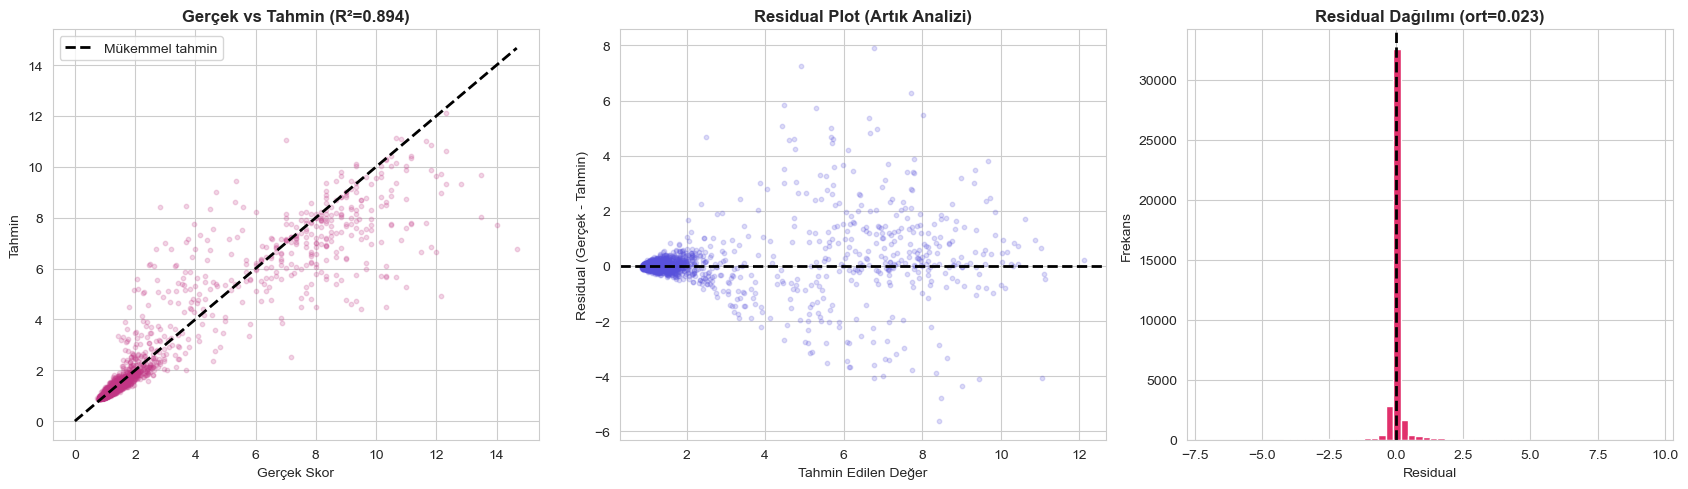

Residual ortalaması sıfıra yakınsa model yanlı (biased) değildir.


In [18]:
# REGRESYON TAHMİN GRAFİKLERİ: Gerçek-vs-Tahmin, Residual Plot ve Residual Dağılımı
pred_o = np.expm1(gb_reg.predict(Xte_p))
residuals = yte_o.values - pred_o
s = np.random.RandomState(1).choice(len(yte_o), 5000, replace=False)

fig, ax = plt.subplots(1, 3, figsize=(17, 5))

# 1) Gerçek vs Tahmin
ax[0].scatter(yte_o.values[s], pred_o[s], alpha=0.2, s=10, color='#C13584')
lim = [0, yte_o.values[s].max()]
ax[0].plot(lim, lim, 'k--', lw=2, label='Mükemmel tahmin')
ax[0].set_xlabel('Gerçek Skor'); ax[0].set_ylabel('Tahmin')
ax[0].set_title(f'Gerçek vs Tahmin (R²={r2_score(yte_o,pred_o):.3f})', fontweight='bold')
ax[0].legend()

# 2) Residual plot (tahmin vs hata)
ax[1].scatter(pred_o[s], residuals[s], alpha=0.2, s=10, color='#5851DB')
ax[1].axhline(0, color='black', lw=2, linestyle='--')
ax[1].set_xlabel('Tahmin Edilen Değer'); ax[1].set_ylabel('Residual (Gerçek - Tahmin)')
ax[1].set_title('Residual Plot (Artık Analizi)', fontweight='bold')

# 3) Residual dağılımı
ax[2].hist(residuals, bins=60, color='#E1306C', edgecolor='white')
ax[2].axvline(0, color='black', lw=2, linestyle='--')
ax[2].set_xlabel('Residual'); ax[2].set_ylabel('Frekans')
ax[2].set_title(f'Residual Dağılımı (ort={residuals.mean():.3f})', fontweight='bold')

plt.tight_layout(); plt.show()
print("Residual ortalaması sıfıra yakınsa model yanlı (biased) değildir.")

### 7.5. Çapraz Doğrulama - Regresyon (Cross-Validation)

Tek bir eğitim/test ayrımının sonucu şansa bağlı olabilir. Bunu test etmek için modelimize **5 katlı çapraz doğrulama** uygulanacaktır: veri 5 parçaya bölünecek, her parça sırayla test rolü oynayacaktır.

**Yorum:** Standart sapmanın çok düşük olması (≈0,0005), modelin verinin hangi bölümüyle test edildiğinden bağımsız olarak **kararlı** çalıştığını ve aşırı öğrenme (overfitting) yaşamadığını kanıtlamaktadır.


In [19]:
# REGRESYON: 5 katlı çapraz doğrulama (model kararlılığı)
pipe_reg = __import__('sklearn.pipeline', fromlist=['Pipeline']).Pipeline([
    ('prep', ColumnTransformer([
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)])),
    ('model', HistGradientBoostingRegressor(learning_rate=0.05, max_depth=8, max_iter=300,
        l2_regularization=1.0, random_state=RANDOM_STATE, early_stopping=True, n_iter_no_change=15))
])
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_reg = cross_val_score(pipe_reg, X_reg, y_reg, cv=kf, scoring='r2')
print("REGRESYON 5-KATLI CV (R², log ölçeği)")
print("="*50)
for i, sc in enumerate(cv_reg, 1): print(f"  Kat {i}: R²={sc:.4f}")
print(f"\nOrtalama: {cv_reg.mean():.4f} | Std: {cv_reg.std():.4f}")


REGRESYON 5-KATLI CV (R², log ölçeği)
  Kat 1: R²=0.9392
  Kat 2: R²=0.9388
  Kat 3: R²=0.9401
  Kat 4: R²=0.9395
  Kat 5: R²=0.9400

Ortalama: 0.9395 | Std: 0.0005


### 7.6. Hiperparametre Optimizasyonu (GridSearchCV)

Bu adımda **GridSearchCV** kullanarak sistematik hiperparametre araması yapılacaktır. Karar Ağacı modeli üzerinde, parametre ızgarasındaki tüm kombinasyonlar 3 katlı çapraz doğrulama ile denenecektir. Varsayılan model ile optimize edilmiş modelin performansı karşılaştırılarak tuning'in somut etkisi gösterilecektir.

In [20]:
# HİPERPARAMETRE OPTİMİZASYONU: GridSearchCV ile sistematik arama
# Karar Ağacı üzerinde, varsayılan model ile optimize model karşılaştırılır.
from sklearn.model_selection import GridSearchCV

# ÖNCE: varsayılan (ayarsız) Karar Ağacı
base_dt = DecisionTreeRegressor(random_state=RANDOM_STATE)
base_dt.fit(Xtr_p, ytr)
r2_before = r2_score(yte_o, np.expm1(base_dt.predict(Xte_p)))
print(f"ÖNCE  (varsayılan Karar Ağacı): R² = {r2_before:.4f}")

# GridSearchCV: parametre ızgarası üzerinde 3 katlı çapraz doğrulamalı arama
param_grid = {
    'max_depth': [8, 12, 16],
    'min_samples_leaf': [1, 5, 10]
}
print(f"\nGridSearchCV çalışıyor ({len(param_grid['max_depth'])*len(param_grid['min_samples_leaf'])} kombinasyon x 3 kat CV)...")
grid = GridSearchCV(DecisionTreeRegressor(random_state=RANDOM_STATE),
                    param_grid, cv=3, scoring='r2', n_jobs=-1)
grid.fit(Xtr_p, ytr)

# SONRA: en iyi parametrelerle optimize model
r2_after = r2_score(yte_o, np.expm1(grid.predict(Xte_p)))
print(f"En iyi parametreler: {grid.best_params_}")
print(f"En iyi CV skoru    : {grid.best_score_:.4f}")
print(f"SONRA (optimize Karar Ağacı)   : R² = {r2_after:.4f}")
print(f"\n>>> İYİLEŞME: {r2_after - r2_before:+.4f} R² puanı <<<")

ÖNCE  (varsayılan Karar Ağacı): R² = 0.7620

GridSearchCV çalışıyor (9 kombinasyon x 3 kat CV)...
En iyi parametreler: {'max_depth': 8, 'min_samples_leaf': 10}
En iyi CV skoru    : 0.9096
SONRA (optimize Karar Ağacı)   : R² = 0.8534

>>> İYİLEŞME: +0.0914 R² puanı <<<


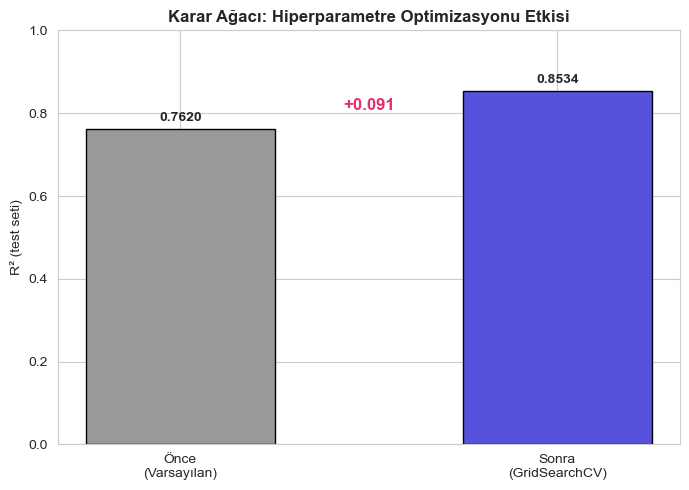

In [22]:
# GÖRSEL: Hiperparametre Tuning Öncesi/Sonrası Karşılaştırması
fig, ax = plt.subplots(figsize=(7, 5))
durumlar = ['Önce\n(Varsayılan)', 'Sonra\n(GridSearchCV)']
degerler = [r2_before, r2_after]
bars = ax.bar(durumlar, degerler, color=['#999999','#5851DB'], edgecolor='black', width=0.5)
ax.set_ylabel('R² (test seti)'); ax.set_ylim(0, 1)
ax.set_title('Karar Ağacı: Hiperparametre Optimizasyonu Etkisi', fontweight='bold')
for b, v in zip(bars, degerler):
    ax.text(b.get_x()+b.get_width()/2, v+0.02, f'{v:.4f}', ha='center', fontweight='bold')
# İyileşme okunu ekle
ax.annotate(f'+{r2_after-r2_before:.3f}', xy=(1, r2_after), xytext=(0.5, (r2_before+r2_after)/2),
            fontsize=12, fontweight='bold', color='#E1306C', ha='center')
plt.tight_layout(); plt.show()

### 7.7. Özellik Önem Sıralaması (Feature Importance)

En iyi regresyon modelinin (Gradient Boosting) hangi özelliklere dayanarak tahmin yaptığını **permutation importance** yöntemiyle inceleyeceğiz. Bu yöntem, bir özelliğin değerleri rastgele karıştırıldığında model performansının ne kadar düştüğünü ölçmektedir; düşüş ne kadar büyükse özellik o kadar önemlidir.

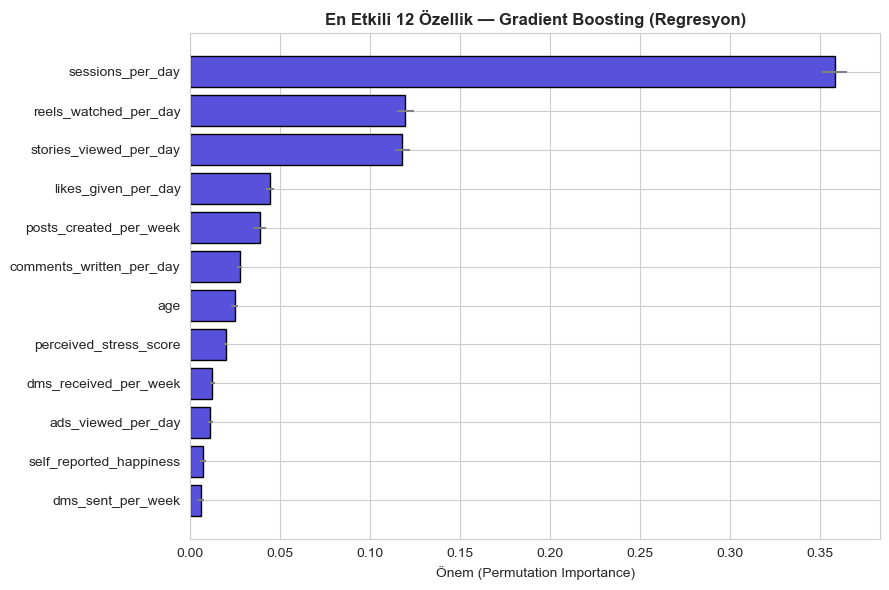

En etkili 5 özellik:
  sessions_per_day                : 0.3580
  reels_watched_per_day           : 0.1194
  stories_viewed_per_day          : 0.1178
  likes_given_per_day             : 0.0441
  posts_created_per_week          : 0.0386


In [23]:
# ÖZELLİK ÖNEM SIRALAMASI (Feature Importance) — Permutation yöntemi
# En iyi regresyon modeli (Gradient Boosting) için her özelliğin tahmindeki katkısı.
from sklearn.inspection import permutation_importance

feat_names = prep_reg.get_feature_names_out()
# Permutation importance hesabı pahalı olduğundan küçük bir test alt örnekleminde yapılır
imp_idx = np.random.RandomState(RANDOM_STATE).choice(len(Xte_p), 3000, replace=False)
perm = permutation_importance(gb_reg, Xte_p[imp_idx], yte.iloc[imp_idx] if hasattr(yte,'iloc') else yte[imp_idx],
                              n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
order = perm.importances_mean.argsort()[::-1][:12]

fig, ax = plt.subplots(figsize=(9, 6))
etiketler = [feat_names[i].replace('num__','').replace('cat__','')[:30] for i in order]
ax.barh(range(len(order)), perm.importances_mean[order], xerr=perm.importances_std[order],
        color='#5851DB', edgecolor='black', ecolor='gray')
ax.set_yticks(range(len(order))); ax.set_yticklabels(etiketler)
ax.invert_yaxis(); ax.set_xlabel('Önem (Permutation Importance)')
ax.set_title('En Etkili 12 Özellik — Gradient Boosting (Regresyon)', fontweight='bold')
plt.tight_layout(); plt.show()

print("En etkili 5 özellik:")
for i in order[:5]:
    print(f"  {feat_names[i].replace('num__','').replace('cat__',''):32s}: {perm.importances_mean[i]:.4f}")

## 8. PROBLEM 2 - Sınıflandırma: Etkileşim Seviyesinin Tahmini

### 8.1. Sınıf Hedefinin Oluşturulması

İkinci problemde aynı veri seti üzerinde farklı bir öğrenme problemi ele alınmaktadır. Sürekli etkileşim skoru, `pd.qcut` fonksiyonu ile **üç dengeli sınıfa** ayrılacaktır: **Düşük, Orta, Yüksek**.

Çeyrekliklere göre bölme, sınıfların yaklaşık eşit büyüklükte olmasını sağlar. Dengeli sınıflar, modelin bir sınıfa yanlı olmasını engeller ve değerlendirme metriklerini (özellikle ROC/AUC) daha anlamlı kılar. Bu yüzden **qcut** kullanılmıştır.


In [24]:
# ============================================================
# PROBLEM 2: SINIFLANDIRMA - Etkileşim seviyesinin tahmini
# ============================================================
# Sürekli skoru 3 dengeli sınıfa ayırıyoruz (qcut ile çeyrekliklere göre)
veri_model['engagement_class'] = pd.qcut(veri_model['user_engagement_score'],
                                        q=3, labels=['Düşük','Orta','Yüksek'])
print("Sınıf dağılımı:")
print(veri_model['engagement_class'].value_counts().sort_index())
print("\nSınıf oranları (%):")
print((veri_model['engagement_class'].value_counts(normalize=True).sort_index()*100).round(1))


Sınıf dağılımı:
Düşük     69035
Orta      64404
Yüksek    66561
Name: engagement_class, dtype: int64

Sınıf oranları (%):
Düşük     34.5
Orta      32.2
Yüksek    33.3
Name: engagement_class, dtype: float64


### 8.2. Train-Validation-Test Ayrımı

Sınıflandırma için veri **üç parçaya** ayrılacaktır: **%60 eğitim, %20 doğrulama (validation), %20 test**.

- **Eğitim seti:** Model bu veriyle öğrenir.
- **Doğrulama seti:** Hiperparametre seçimi bu sette yapılır (test setine dokunmadan).
- **Test seti:** Yalnızca en sonda, modelin gerçek performansını ölçmek için kullanılır.

`stratify` parametresi her bölümde sınıf oranlarının korunmasını sağlayacaktr, bu husus dengeli değerlendirme için önemlidir.


In [25]:
# SINIFLANDIRMA: Hedef kodlama ve train-validation-test ayrımı (%60-20-20)
le = LabelEncoder()
y_clf = le.fit_transform(veri_model['engagement_class'])
print("Sınıf Kodlaması:", dict(zip(le.classes_, range(len(le.classes_)))))

X_clf = veri_model.drop(columns=['user_engagement_score','engagement_class'] + leak_cols)

# Önce train+temp (60/40), sonra temp'i val/test (20/20) - stratify ile dengeli
Xc_tr, Xc_temp, yc_tr, yc_temp = train_test_split(
    X_clf, y_clf, test_size=0.4, stratify=y_clf, random_state=RANDOM_STATE)
Xc_val, Xc_te, yc_val, yc_te = train_test_split(
    Xc_temp, yc_temp, test_size=0.5, stratify=yc_temp, random_state=RANDOM_STATE)
print(f"\nEğitim    : {Xc_tr.shape[0]:,} (%60)")
print(f"Validation: {Xc_val.shape[0]:,} (%20)")
print(f"Test      : {Xc_te.shape[0]:,} (%20)\n")

# Ön işleme
prep_clf = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)])
Xc_tr_p = prep_clf.fit_transform(Xc_tr)
Xc_val_p = prep_clf.transform(Xc_val)
Xc_te_p = prep_clf.transform(Xc_te)
print("Ön İşleme Tamamlandı.")


Sınıf Kodlaması: {'Düşük': 0, 'Orta': 1, 'Yüksek': 2}

Eğitim    : 120,000 (%60)
Validation: 40,000 (%20)
Test      : 40,000 (%20)

Ön İşleme Tamamlandı.


### 8.3. Sınıflandırma Modellerinin Eğitimi (4 Farklı Aile)

Sınıflandırma modellerinin performansı üç metrikle değerlendirilecektir: **doğruluk (accuracy)** ve **F1-macro** skoru ve **eğitim süresi**.


In [26]:
# SINIFLANDIRMA MODELLERİ: 4 FARKLI ALGORİTMA AİLESİNDEN model (validation seti)
# Aileler: Mesafe (KNN) | Çekirdek (SVM) | Bagging (RF) | Boosting (GB)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

svm_idx_c = np.random.RandomState(RANDOM_STATE).choice(len(Xc_tr_p), 10000, replace=False)

def clf_degerlendir(isim, model, kucuk_ornek=False):
    t0 = time.time()
    if kucuk_ornek:
        model.fit(Xc_tr_p[svm_idx_c], yc_tr[svm_idx_c])
    else:
        model.fit(Xc_tr_p, yc_tr)
    sure = time.time() - t0
    p = model.predict(Xc_val_p)
    acc = accuracy_score(yc_val, p); f1 = f1_score(yc_val, p, average="macro")
    print(f"{isim:26s} | Doğruluk={acc:.4f} | F1(macro)={f1:.4f} | Süre={sure:.2f}s")
    return model, acc, f1, sure

print("SINIFLANDIRMA MODELLERİ — 4 ALGORİTMA AİLESİ (Validation Seti)")
print("="*78)
clf_results = {}
# 1) Mesafe-tabanlı
knn_clf, acc, f1, sure = clf_degerlendir("1. KNN (k=15)",
            KNeighborsClassifier(n_neighbors=15, n_jobs=-1))
clf_results["KNN"] = (acc, f1, sure)
# 2) Çekirdek-tabanlı (alt örneklemde)
svc, acc, f1, sure = clf_degerlendir("2. SVM (RBF çekirdek)",
            SVC(kernel="rbf", C=1.0, probability=False, random_state=RANDOM_STATE), kucuk_ornek=True)
clf_results["SVM"] = (acc, f1, sure)
# 3) Bagging
rf, acc, f1, sure = clf_degerlendir("3. Random Forest",
            RandomForestClassifier(n_estimators=100, max_depth=15, n_jobs=-1, random_state=RANDOM_STATE))
clf_results["Random Forest"] = (acc, f1, sure)
# 4) Boosting
gb_clf, acc, f1, sure = clf_degerlendir("4. Gradient Boosting",
            HistGradientBoostingClassifier(learning_rate=0.05, max_depth=8, max_iter=300,
            l2_regularization=1.0, random_state=RANDOM_STATE))
clf_results["Gradient Boosting"] = (acc, f1, sure)

SINIFLANDIRMA MODELLERİ — 4 ALGORİTMA AİLESİ (Validation Seti)
1. KNN (k=15)              | Doğruluk=0.6681 | F1(macro)=0.6635 | Süre=0.04s
2. SVM (RBF çekirdek)      | Doğruluk=0.7548 | F1(macro)=0.7554 | Süre=5.85s
3. Random Forest           | Doğruluk=0.7417 | F1(macro)=0.7423 | Süre=8.48s
4. Gradient Boosting       | Doğruluk=0.8003 | F1(macro)=0.8003 | Süre=35.86s


### 8.4. Sınıflandırma Modellerinin Karşılaştırılması

Sınıflandırma modelleri farklı açılardan karşılaştırılacaktır:
- **Sol (Doğruluk):** Doğru tahmin oranı - yüksek = iyi.
- **Orta (F1-macro):** Sınıflar arası dengeli başarı - yüksek = iyi.
- **Sağ (Eğitim Süresi):** Modelin eğitilme süresi (saniye) - düşük = hızlı.

**Değerlendirme:** Regresyonda olduğu gibi, Gradient Boosting en yüksek doğruluğu sağlamaktadır ancak eğitimi en uzun süren modeldir. Bu karşılaştırma, model seçiminde yalnızca doğruluğun değil, hesaplama maliyetinin de göz önünde bulundurulması gerektiğini vurgulamaktadır.

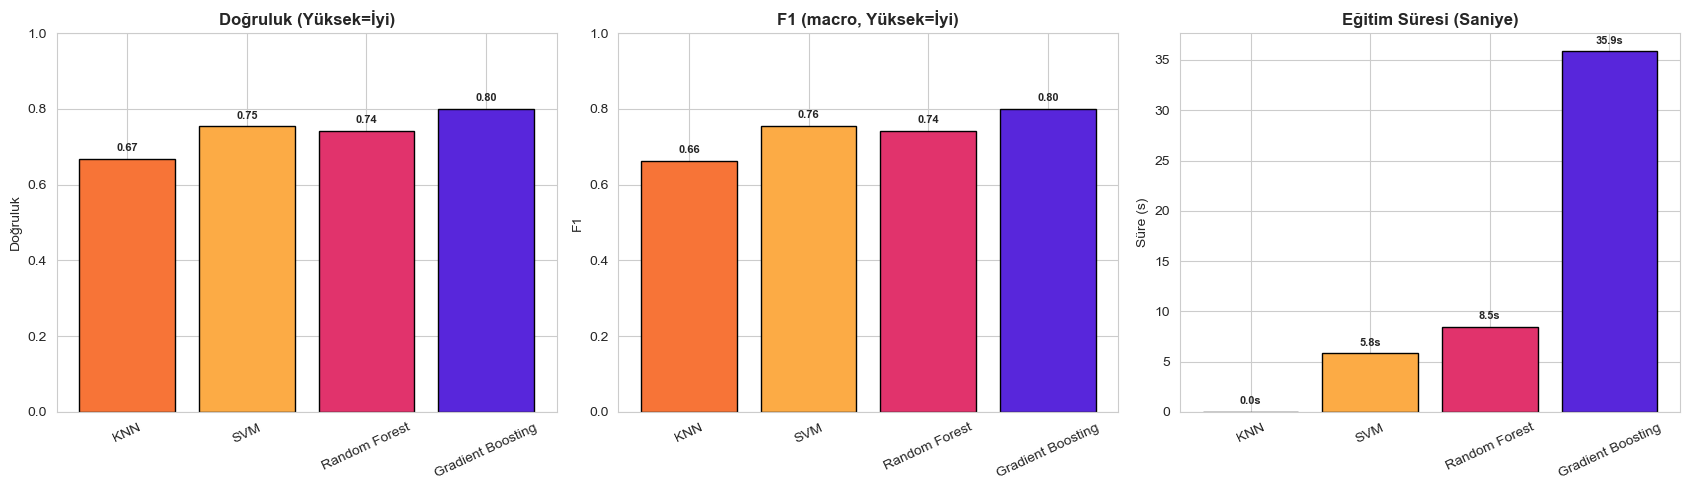

In [27]:
# GÖRSEL: 4 Sınıflandırma Modelinin Karşılaştırması (Doğruluk, F1, Süre)
fig, ax = plt.subplots(1, 3, figsize=(17, 5))
isimler_c = list(clf_results.keys())
acclar = [clf_results[k][0] for k in isimler_c]
f1ler = [clf_results[k][1] for k in isimler_c]
sureler_c = [clf_results[k][2] for k in isimler_c]
renk_c = ['#F77437','#FCAB45','#E1336C','#5826DB']

b1 = ax[0].bar(isimler_c, acclar, color=renk_c, edgecolor='black')
ax[0].set_title('Doğruluk (Yüksek=İyi)', fontweight='bold'); ax[0].set_ylabel('Doğruluk'); ax[0].set_ylim(0,1)
ax[0].tick_params(axis='x', rotation=25)
for b,v in zip(b1,acclar): ax[0].text(b.get_x()+b.get_width()/2,v+0.02,f'{v:.2f}',ha='center',fontsize=8,fontweight='bold')

b2 = ax[1].bar(isimler_c, f1ler, color=renk_c, edgecolor='black')
ax[1].set_title('F1 (macro, Yüksek=İyi)', fontweight='bold'); ax[1].set_ylabel('F1'); ax[1].set_ylim(0,1)
ax[1].tick_params(axis='x', rotation=25)
for b,v in zip(b2,f1ler): ax[1].text(b.get_x()+b.get_width()/2,v+0.02,f'{v:.2f}',ha='center',fontsize=8,fontweight='bold')

b3 = ax[2].bar(isimler_c, sureler_c, color=renk_c, edgecolor='black')
ax[2].set_title('Eğitim Süresi (Saniye)', fontweight='bold'); ax[2].set_ylabel('Süre (s)')
ax[2].tick_params(axis='x', rotation=25)
for b,v in zip(b3,sureler_c): ax[2].text(b.get_x()+b.get_width()/2,v+max(sureler_c)*0.02,f'{v:.1f}s',ha='center',fontsize=8,fontweight='bold')

plt.tight_layout(); plt.show()

### 8.5. Hiperparametre Optimizasyonu (Hyperparameter Tuning)

En iyi performansı gösteren Gradient Boosting modeli için farklı hiperparametre kombinasyonları denenecektir:
- `learning_rate` (öğrenme hızı): Her ağacın katkı ağırlığı.
- `max_depth` (ağaç derinliği): Modelin karmaşıklık kapasitesi.
- `max_iter` (iterasyon sayısı): Kurulacak ağaç sayısı.

Doğrulama setinde en yüksek doğruluğu veren kombinasyon seçilerek model iyileştirilecektir.


In [28]:
# HİPERPARAMETRE TUNING: Gradient Boosting (en iyi model)
print("HİPERPARAMETRE TUNING (validation seti)")
print("="*60)
combos = [(0.1,6,300),(0.05,8,400),(0.15,6,300)]
best_acc, best_model = 0, None
for lr, depth, iters in combos:
    m = HistGradientBoostingClassifier(learning_rate=lr, max_depth=depth, max_iter=iters,
        l2_regularization=1.0, random_state=RANDOM_STATE, early_stopping=True, n_iter_no_change=12)
    m.fit(Xc_tr_p, yc_tr)
    acc = accuracy_score(yc_val, m.predict(Xc_val_p))
    print(f"lr={lr:<5} depth={depth:<3} iter={iters:<4} | Doğruluk={acc:.4f}")
    if acc > best_acc: best_acc, best_model = acc, m
print(f"\nEn İyi Doğruluk: {best_acc:.4f}")


HİPERPARAMETRE TUNING (validation seti)
lr=0.1   depth=6   iter=300  | Doğruluk=0.7994
lr=0.05  depth=8   iter=400  | Doğruluk=0.8000
lr=0.15  depth=6   iter=300  | Doğruluk=0.7984

En İyi Doğruluk: 0.8000


### 8.6. Test Setinde Nihai Değerlendirme

Optimize edilen model, daha önce hiç görmediği test setinde değerlendirilecektir. `classification_report` her sınıf için ayrı ayrı precision (kesinlik), recall (duyarlılık) ve F1 skorlarını sunmaktadır. Böylece, modelin hangi sınıflarda daha başarılı/zayıf olduğu görülecektir.


In [29]:
# SINIFLANDIRMA: Test setinde nihai değerlendirme + sınıf raporu
gb_clf = best_model
pred_te = gb_clf.predict(Xc_te_p)
proba_te = gb_clf.predict_proba(Xc_te_p)
print("TEST SETİ - Gradient Boosting (En İyi Model)")
print("="*60)
print(classification_report(yc_te, pred_te, target_names=le.classes_))


TEST SETİ - Gradient Boosting (En İyi Model)
              precision    recall  f1-score   support

       Düşük       0.83      0.81      0.82     13807
        Orta       0.69      0.72      0.70     12881
      Yüksek       0.90      0.88      0.89     13312

    accuracy                           0.80     40000
   macro avg       0.80      0.80      0.80     40000
weighted avg       0.80      0.80      0.80     40000



### 8.7. Confusion Matrix ve ROC Eğrisi

- **Confusion Matrix (Karmaşıklık Matrisi):** Hangi sınıfların birbirine karıştırıldığını gösterir. Güçlü bir köşegen yüksek doğruluğa işaret eder. Hataların komşu sınıflar arasında olması (Düşük-Orta, Orta-Yüksek) beklenen bir durumdur.

- **ROC Eğrisi:** Eğri sol-üst köşeye ne kadar yakınsa o kadar iyidir. **AUC** (eğri altı alan) değeri 1'e yaklaştıkça modelin o sınıfı ne kadar iyi ayırt ettiği anlaşılır.

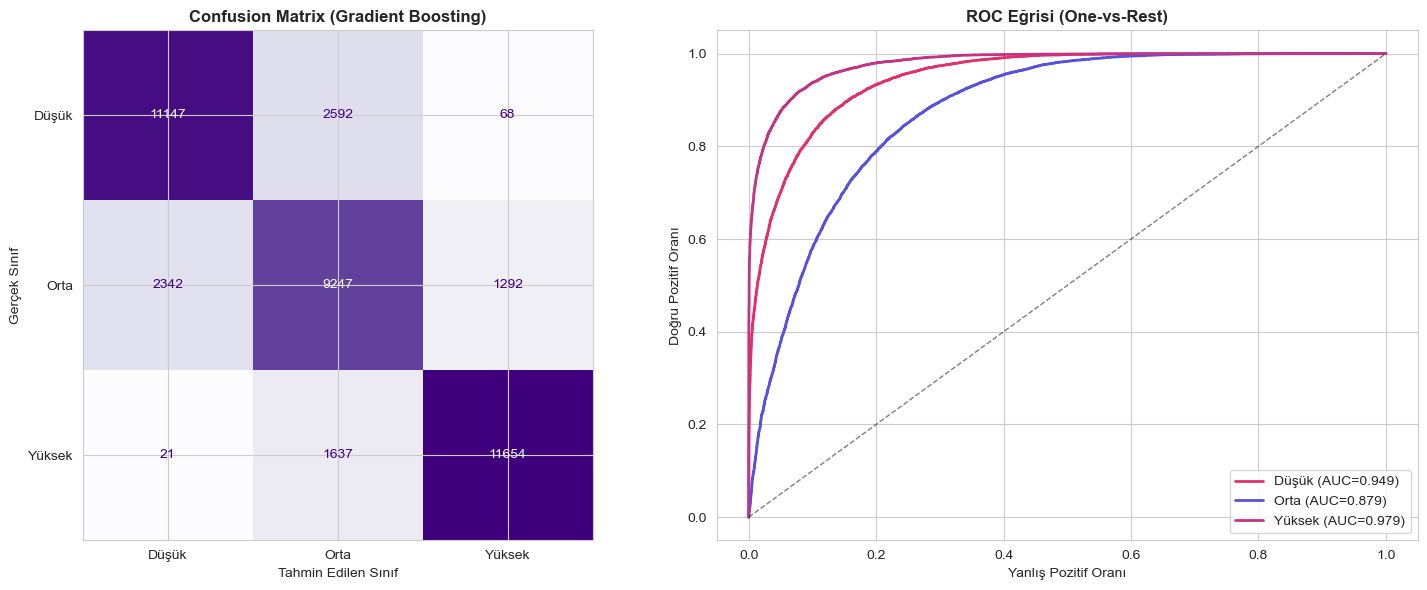

In [30]:
# GÖRSEL 7: Confusion Matrix ve ROC Eğrisi (ölçüt gereği)
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Confusion Matrix
cm = confusion_matrix(yc_te, pred_te)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax[0], cmap='Purples', colorbar=False, values_format='d')
ax[0].set_title('Confusion Matrix (Gradient Boosting)', fontweight='bold')
ax[0].set_xlabel('Tahmin Edilen Sınıf'); ax[0].set_ylabel('Gerçek Sınıf')

# ROC Curve (One-vs-Rest, çok sınıflı)
y_bin = label_binarize(yc_te, classes=[0,1,2])
renkler = ['#E1306C','#5851DB','#C13584']
for i, (c, renk) in enumerate(zip(le.classes_, renkler)):
    fpr, tpr, _ = roc_curve(y_bin[:,i], proba_te[:,i])
    ax[1].plot(fpr, tpr, color=renk, lw=2, label=f'{c} (AUC={auc(fpr,tpr):.3f})')
ax[1].plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
ax[1].set_xlabel('Yanlış Pozitif Oranı'); ax[1].set_ylabel('Doğru Pozitif Oranı')
ax[1].set_title('ROC Eğrisi (One-vs-Rest)', fontweight='bold')
ax[1].legend(loc='lower right')
plt.tight_layout(); plt.show()


### 8.8. Çapraz Doğrulama - Sınıflandırma

Sınıflandırma modelinin kararlılığı **5 katlı çapraz doğrulama** ile test edilecektir. Düşük standart sapma, sınıflandırma modelinin de tıpkı regresyon modeli gibi güvenilir ve tutarlı olduğunu göstermektedir.


In [31]:
# SINIFLANDIRMA: 5 katlı çapraz doğrulama (Stratified, kararlılık)
X_all = np.vstack([Xc_tr_p, Xc_val_p]); y_all = np.concatenate([yc_tr, yc_val])
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_clf = []
for tr_idx, te_idx in skf.split(X_all, y_all):
    m = HistGradientBoostingClassifier(learning_rate=0.1, max_depth=6, max_iter=150,
        l2_regularization=1.0, random_state=RANDOM_STATE)
    m.fit(X_all[tr_idx], y_all[tr_idx])
    cv_clf.append(accuracy_score(y_all[te_idx], m.predict(X_all[te_idx])))
cv_clf = np.array(cv_clf)
print("SINIFLANDIRMA 5-KATLI CV (Doğruluk)")
print("="*50)
for i, sc in enumerate(cv_clf, 1): print(f"  Kat {i}: Doğruluk={sc:.4f}")
print(f"\nOrtalama: {cv_clf.mean():.4f} | Std: {cv_clf.std():.4f}")


SINIFLANDIRMA 5-KATLI CV (Doğruluk)
  Kat 1: Doğruluk=0.7960
  Kat 2: Doğruluk=0.7952
  Kat 3: Doğruluk=0.8008
  Kat 4: Doğruluk=0.7953
  Kat 5: Doğruluk=0.7998

Ortalama: 0.7974 | Std: 0.0024


## 9. Sonuç ve Özet (Conclusion)

**1.** Kullanıcı etkileşimini en çok belirleyen faktör, günlük **oturum sayısıdır** (`sessions_per_day`). Bunu reels izleme ve story görüntüleme gibi içerik tüketim davranışları takip etmektedir. Buna karşın egzersiz, uyku gibi yaşam tarzı değişkenlerinin etkisi sınırlıdır.

**2.** İlk modellerin şüphe uyandıracak kadar yüksek başarısı (R²≈0,99) bir veri sızıntısının işareti olarak algılanmıştır. Bu, veri madenciliğinde yüksek performansın her zaman olumlu olmadığını, dikkatli incelemenin önemini göstermektedir.


In [32]:
# SONUÇ ÖZETİ: Her iki problemin nihai performansı
print("="*60)
print("PROJE SONUÇ ÖZETİ")
print("="*60)
print("\n[PROBLEM 1] REGRESYON (Etkileşim Skoru Tahmini)")
print(f"  En iyi model    : Gradient Boosting")
print(f"  Test R²         : {reg_results['Gradient Boosting'][0]:.4f}")
print(f"  Test MAE        : {reg_results['Gradient Boosting'][1]:.4f}")
print(f"  Eğitim süresi   : {reg_results['Gradient Boosting'][2]:.2f}s")
print(f"  5-katlı CV R²   : {cv_reg.mean():.4f} (±{cv_reg.std():.4f})")
print("\n[PROBLEM 2] SINIFLANDIRMA (Etkileşim Seviyesi)")
print(f"  En iyi model    : Gradient Boosting")
print(f"  Test Doğruluk   : {accuracy_score(yc_te, pred_te):.4f}")
print(f"  Test F1 (macro) : {f1_score(yc_te, pred_te, average='macro'):.4f}")
print(f"  5-katlı CV Doğr.: {cv_clf.mean():.4f} (±{cv_clf.std():.4f})")
print("\nTEMEL BULGU: Etkileşimi en çok 'sessions_per_day' (oturum sıklığı) belirlemektedir.")


PROJE SONUÇ ÖZETİ

[PROBLEM 1] REGRESYON (Etkileşim Skoru Tahmini)
  En iyi model    : Gradient Boosting
  Test R²         : 0.8943
  Test MAE        : 0.1844
  Eğitim süresi   : 14.48s
  5-katlı CV R²   : 0.9395 (±0.0005)

[PROBLEM 2] SINIFLANDIRMA (Etkileşim Seviyesi)
  En iyi model    : Gradient Boosting
  Test Doğruluk   : 0.8012
  Test F1 (macro) : 0.8011
  5-katlı CV Doğr.: 0.7974 (±0.0024)

TEMEL BULGU: Etkileşimi en çok 'sessions_per_day' (oturum sıklığı) belirlemektedir.
